# 06 Feature Selection

Analyze the latest available ML dataset using config-driven paths. Supporting reusable code now lives in `src/feature_selection.py`, while this notebook remains the interactive analysis surface.


In [7]:
import os
import sys
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sys.path.append(os.path.abspath('..'))
from src.utils import load_config

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

config = load_config('../configs/config.yaml')
paths = config['paths']
processed_dir = Path('..') / paths['processed_data_dir']
output_dir = Path('..') / 'outputs' / 'feature_analysis'
output_dir.mkdir(parents=True, exist_ok=True)

primary_dataset_path = processed_dir / paths['ml_dataset_file']
fallback_dataset_path = processed_dir / 'ml_dataset_labeled.parquet'
dataset_path = primary_dataset_path if primary_dataset_path.exists() else fallback_dataset_path

if dataset_path.exists():
    df = pd.read_parquet(dataset_path)
    print(f'Loaded feature-selection dataset from {dataset_path}')
    print(f'Dataset size: {len(df):,} rows x {len(df.columns):,} columns')
    display(df.head())
else:
    raise FileNotFoundError(
        f'No ML dataset found at {primary_dataset_path} or {fallback_dataset_path}. Run notebook 04 or the weather/label/validate pipeline stages first.'
    )

excluded_numeric = {'delay_minutes', 'cancelled'}
numeric_cols = [
    col for col in df.select_dtypes(include=[np.number]).columns.tolist()
    if col not in excluded_numeric
]
target_col = 'delay_minutes' if 'delay_minutes' in df.columns else None
print(f'Using {len(numeric_cols):,} numeric feature columns for analysis.')


Loaded feature-selection dataset from ..\data\processed\ml_dataset.parquet
Dataset size: 83,289 rows x 35 columns


,flight_key,region,source_dataset,scheduled_dep,scheduled_arr,origin,destination,cancelled,flight_duration,trajectory_length,...,weather_confidence,match_quality,label_source,match_score_minutes,match_anchor,match_confidence,training_eligible,feature_quality_score,delay_minutes,label
0,B633_20220501,US,bts,2022-05-01 16:00:00+00:00,2022-05-01 22:43:00+00:00,KBOS,KSFO,0,1660.0,0.000000,...,None,multi_anchor_service_day<180m,bts_verified,112.666667,arrival,0.121622,False,0.529412,6.0,Normal
1,UA1540_20220501,US,bts,2022-05-01 16:35:00+00:00,2022-05-01 22:05:00+00:00,KSFO,KRSW,0,590.0,48.380599,...,None,multi_anchor_service_day<180m,bts_verified,125.000000,arrival,0.113514,True,0.705882,22.0,Late
2,WN606_20220501,US,bts,2022-05-01 17:25:00+00:00,2022-05-01 21:50:00+00:00,KMIA,KDEN,0,980.0,140.128264,...,None,multi_anchor_service_day<180m,bts_verified,146.500000,arrival,0.101695,True,0.705882,-5.0,Normal
3,UA1172_20220501,US,bts,2022-05-01 17:40:00+00:00,2022-05-02 00:22:00+00:00,KBOS,KSFO,0,700.0,17.937088,...,None,multi_anchor_service_day<180m,bts_verified,10.166667,arrival,0.299287,True,0.705882,-1.0,Normal
4,WN1083_20220501,US,bts,2022-05-01 17:45:00+00:00,2022-05-01 23:10:00+00:00,PHNL,KSAN,0,3120.0,528.915144,...,None,multi_anchor_service_day<180m,bts_verified,121.500000,arrival,0.330579,True,0.705882,8.0,Normal


Using 19 numeric feature columns for analysis.


## Missingness Heatmap

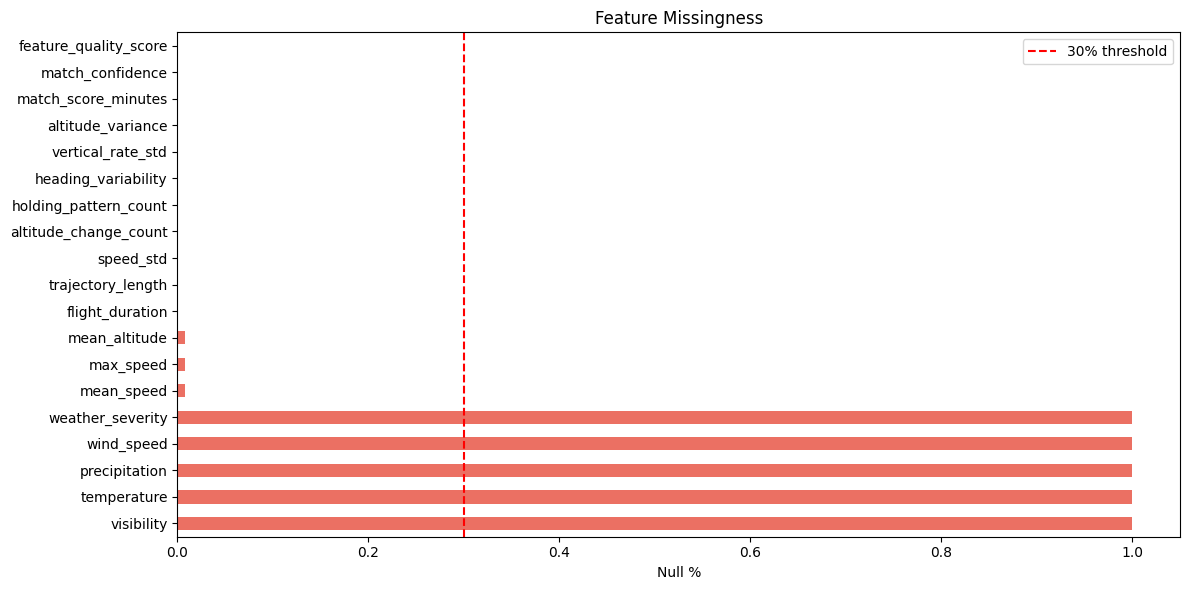

Saved to ..\outputs\feature_analysis\missingness_heatmap.png


In [8]:
if numeric_cols:
    null_pct = df[numeric_cols].isnull().mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(12, max(6, len(numeric_cols) * 0.3)))
    null_pct.plot(kind='barh', ax=ax, color='#e74c3c', alpha=0.8)
    ax.set_xlabel('Null %')
    ax.set_title('Feature Missingness')
    ax.axvline(x=0.3, color='red', linestyle='--', label='30% threshold')
    ax.legend()
    plt.tight_layout()
    fig.savefig(output_dir / 'missingness_heatmap.png', dpi=150)
    plt.show()
    plt.close(fig)
    print(f'Saved to {output_dir / "missingness_heatmap.png"}')
else:
    print('No numeric feature columns are available for missingness analysis.')


## Correlation Matrix

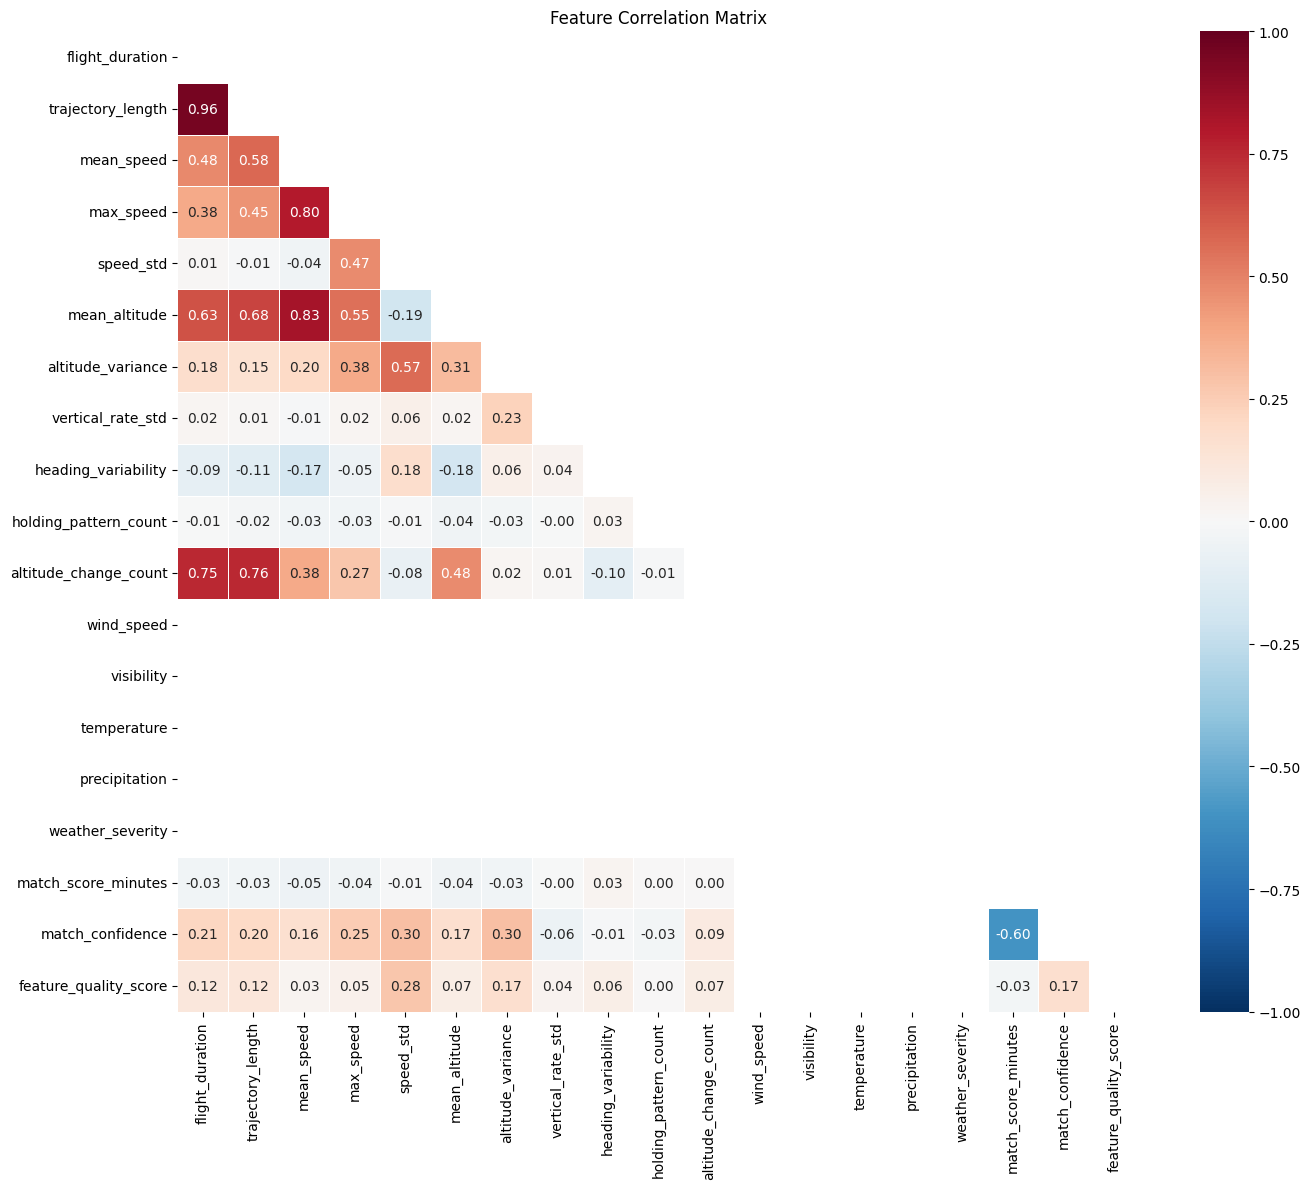

Saved to ..\outputs\feature_analysis\correlation_matrix.png


,feature_a,feature_b,correlation
0,flight_duration,trajectory_length,0.9594


In [9]:
if numeric_cols:
    corr = df[numeric_cols].corr()
    fig, ax = plt.subplots(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
    ax.set_title('Feature Correlation Matrix')
    plt.tight_layout()
    fig.savefig(output_dir / 'correlation_matrix.png', dpi=150)
    plt.show()
    plt.close(fig)
    print(f'Saved to {output_dir / "correlation_matrix.png"}')

    high_corr = []
    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):
            if abs(corr.iloc[i, j]) > 0.85:
                high_corr.append({
                    'feature_a': corr.columns[i],
                    'feature_b': corr.columns[j],
                    'correlation': round(corr.iloc[i, j], 4),
                })
    if high_corr:
        display(pd.DataFrame(high_corr))
else:
    print('No numeric feature columns are available for correlation analysis.')


## Mutual Information

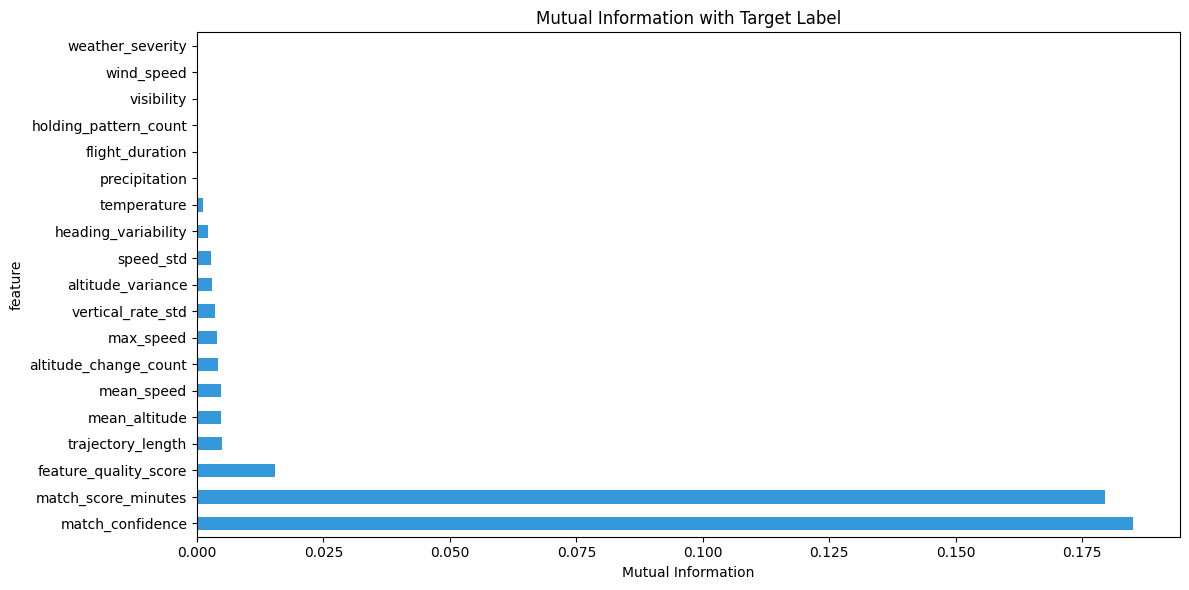

,feature,mutual_info
17,match_confidence,0.185105
16,match_score_minutes,0.179537
18,feature_quality_score,0.015395
1,trajectory_length,0.004887
5,mean_altitude,0.004738
2,mean_speed,0.004736
10,altitude_change_count,0.004104
3,max_speed,0.003882
7,vertical_rate_std,0.003614
6,altitude_variance,0.002895


Saved to ..\outputs\feature_analysis\mutual_information.csv


In [10]:
try:
    from sklearn.feature_selection import mutual_info_classif
    from sklearn.preprocessing import LabelEncoder

    if 'label' in df.columns and numeric_cols:
        X_mi = df[numeric_cols].fillna(0)
        y_mi = LabelEncoder().fit_transform(df['label'])
        mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
        mi_df = pd.DataFrame({'feature': numeric_cols, 'mutual_info': mi_scores}).sort_values('mutual_info', ascending=False)

        fig, ax = plt.subplots(figsize=(12, max(6, len(numeric_cols) * 0.3)))
        mi_df.plot(x='feature', y='mutual_info', kind='barh', ax=ax, color='#3498db', legend=False)
        ax.set_xlabel('Mutual Information')
        ax.set_title('Mutual Information with Target Label')
        plt.tight_layout()
        fig.savefig(output_dir / 'mutual_information.png', dpi=150)
        plt.show()
        plt.close(fig)

        mi_df.to_csv(output_dir / 'mutual_information.csv', index=False)
        display(mi_df.head(15))
        print(f'Saved to {output_dir / "mutual_information.csv"}')
    else:
        print('Mutual information requires both numeric features and a label column.')
except Exception as exc:
    print(f'Mutual information computation failed: {exc}')


## Permutation Importance

In [11]:
try:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.impute import SimpleImputer
    from sklearn.inspection import permutation_importance
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import LabelEncoder

    if 'label' in df.columns and numeric_cols:
        X_pi = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(df[numeric_cols]), columns=numeric_cols)
        y_pi = LabelEncoder().fit_transform(df['label'])
        X_tr, X_te, y_tr, y_te = train_test_split(X_pi, y_pi, test_size=0.3, random_state=42, stratify=y_pi)

        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_tr, y_tr)

        perm = permutation_importance(rf, X_te, y_te, n_repeats=10, random_state=42, n_jobs=-1)
        perm_df = pd.DataFrame({
            'feature': numeric_cols,
            'importance_mean': perm.importances_mean,
            'importance_std': perm.importances_std,
        }).sort_values('importance_mean', ascending=False)

        fig, ax = plt.subplots(figsize=(12, max(6, len(numeric_cols) * 0.3)))
        perm_df.plot(
            x='feature',
            y='importance_mean',
            xerr='importance_std',
            kind='barh',
            ax=ax,
            color='#2ecc71',
            legend=False,
            capsize=3,
        )
        ax.set_xlabel('Permutation Importance')
        ax.set_title('Permutation Importance (Random Forest)')
        plt.tight_layout()
        fig.savefig(output_dir / 'permutation_importance.png', dpi=150)
        plt.show()
        plt.close(fig)

        perm_df.to_csv(output_dir / 'permutation_importance.csv', index=False)
        display(perm_df.head(15))
        print(f'Saved to {output_dir / "permutation_importance.csv"}')
    else:
        print('Permutation importance requires both numeric features and a label column.')
except Exception as exc:
    print(f'Permutation importance failed: {exc}')


Permutation importance failed: Shape of passed values is (83289, 14), indices imply (83289, 19)


d:\Desertation\Code_v3\.venv11\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['wind_speed' 'visibility' 'temperature' 'precipitation'
 'weather_severity']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


## Leakage Risk Table

In [12]:
leakage_risks = []
known_leaky = ['actual_dep', 'actual_arr', 'delay_minutes']

for col in df.columns:
    risk = 'NONE'
    reason = ''

    if col in known_leaky:
        risk = 'HIGH'
        reason = 'Direct target info / post-hoc measurement'
    elif col == 'cancelled':
        risk = 'MODERATE'
        reason = 'May be known in advance but strongly correlates with target'
    elif target_col and col in numeric_cols and target_col in df.columns:
        corr_val = df[col].corr(df[target_col])
        if pd.notna(corr_val):
            if abs(corr_val) > 0.9:
                risk = 'HIGH'
                reason = f'Very high correlation with target (r={corr_val:.3f})'
            elif abs(corr_val) > 0.7:
                risk = 'MODERATE'
                reason = f'High correlation with target (r={corr_val:.3f})'

    if risk != 'NONE':
        leakage_risks.append({'column': col, 'risk_level': risk, 'reason': reason})

leak_df = pd.DataFrame(leakage_risks)
if not leak_df.empty:
    leak_df.to_csv(output_dir / 'leakage_risk_table.csv', index=False)
    display(leak_df)
    print(f'Saved to {output_dir / "leakage_risk_table.csv"}')
else:
    print('No elevated leakage risks were detected by the current rules.')


,column,risk_level,reason
0,cancelled,MODERATE,May be known in advance but strongly correlate...
1,delay_minutes,HIGH,Direct target info / post-hoc measurement


Saved to ..\outputs\feature_analysis\leakage_risk_table.csv
